# 04 — Baselines de détection d'anomalies
## Merapi Anomaly Detection — Phase 4

**Objectifs :**
1. Calculer des scores d'anomalie par méthodes simples (sans deep learning)
2. Comparer les images consécutives (MAD, SSIM)
3. Détecter l'incandescence nocturne (luminosité anormale la nuit)
4. Comparer les images à heure similaire sur des jours consécutifs
5. Identifier les images les plus « anormales » du mois

**Méthodes baseline :**
- **MAD** (Mean Absolute Difference) : différence pixel à pixel entre images consécutives
- **SSIM** (Structural Similarity Index) : similarité structurelle → 1 − SSIM = score d'anomalie
- **Luminosité nocturne** : fraction de pixels lumineux sur images de nuit (incandescence)
- **Comparaison heure fixe** : même créneau horaire, jours consécutifs

## 0. Imports et configuration

In [1]:
import sys
from pathlib import Path

# Racine du projet
PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import load_config, setup_logger, get_index_path, PROJECT_ROOT as SRC_ROOT
from src.preprocessing import MerapiPreprocessor
from src.baselines import BaselineDetector
from src.indexer import MerapiIndexer

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (12, 5)})

config = load_config()
setup_logger(config)

FIGURES_DIR = SRC_ROOT / config["paths"]["figures"]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SCORES_DIR = SRC_ROOT / config["paths"]["scores"]
SCORES_DIR.mkdir(parents=True, exist_ok=True)

detector = BaselineDetector(config)
indexer = MerapiIndexer(config)

print("Configuration chargee :", config["project"]["name"])

15:36:50 | INFO     | src.utils:163 — Logger initialisé — niveau : INFO


Configuration chargee : merapi_anomaly


## 1. Chargement de l'index

In [2]:
index_real = get_index_path(config)
index_demo = SRC_ROOT / "data" / "index" / "index_demo.csv"

if index_real.exists():
    df = pd.read_csv(index_real, dtype=str, na_values=["", "None", "nan"])
    SOURCE = "reel"
else:
    df = pd.read_csv(index_demo, dtype=str, na_values=["", "None", "nan"])
    SOURCE = "demo"

for c in ["year", "month", "day", "hour", "minute"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["downloaded"] = df["downloaded"].map(lambda x: str(x).lower() == "true")
df["file_size_bytes"] = pd.to_numeric(df["file_size_bytes"], errors="coerce")
df["anomaly_score"] = pd.to_numeric(df.get("anomaly_score", pd.Series(dtype=float)), errors="coerce")

# Filtrer les images telechargeees
df_dl = df[df["downloaded"] == True].copy()
print(f"Index {SOURCE} : {len(df)} images, {len(df_dl)} telechargeees")
df_dl.head()

Index reel : 119 images, 70 telechargeees


,url,filename,local_path,extension,year,month,day,hour,minute,second,downloaded,file_size_bytes,quality_flag,is_night,anomaly_score,notes
0,http://wwwobs.univ-bpclermont.fr/SO/televolc/s...,Kalor_Canon_2014-11-12_17.13.07.jpg,/Users/knightpetersonjean-baptiste/Desktop/Sta...,.jpg,2014,11,NaN,NaN,NaN,NaN,True,2286.0,usable,NaN,0.000000,NaN
1,http://wwwobs.univ-bpclermont.fr/SO/televolc/s...,Kalor_Canon_2014-11-12_22.12.54.jpg,/Users/knightpetersonjean-baptiste/Desktop/Sta...,.jpg,2014,11,NaN,NaN,NaN,NaN,True,2286.0,usable,NaN,0.235524,NaN
2,http://wwwobs.univ-bpclermont.fr/SO/televolc/s...,Kalor_Canon_2014-11-13_00.12.53.jpg,/Users/knightpetersonjean-baptiste/Desktop/Sta...,.jpg,2014,11,NaN,NaN,NaN,NaN,True,1790.0,usable,NaN,0.136073,NaN
3,http://wwwobs.univ-bpclermont.fr/SO/televolc/s...,Kalor_Canon_2014-11-13_01.12.32.jpg,/Users/knightpetersonjean-baptiste/Desktop/Sta...,.jpg,2014,11,NaN,NaN,NaN,NaN,True,2180.0,usable,NaN,0.079155,NaN
4,http://wwwobs.univ-bpclermont.fr/SO/televolc/s...,Kalor_Canon_2014-11-13_02.12.32.jpg,/Users/knightpetersonjean-baptiste/Desktop/Sta...,.jpg,2014,11,NaN,NaN,NaN,NaN,True,2323.0,usable,NaN,0.147740,NaN


## 2. Verification des images pretraitees

Les baselines travaillent sur les `.npy` generees par `preprocessing.py`.  
Verifions qu'elles existent.

In [3]:
def check_processed(row):
    """Verifie si le .npy existe pour une image."""
    raw_rel = str(row["local_path"])
    proc_rel = raw_rel.replace(
        config["paths"]["data_raw"],
        config["paths"]["data_processed"],
    )
    npy_path = (SRC_ROOT / proc_rel).with_suffix(".npy")
    return npy_path.exists()

df_dl["has_npy"] = df_dl.apply(check_processed, axis=1)
n_ready = df_dl["has_npy"].sum()
n_total = len(df_dl)

print(f"Images pretraitees (.npy) : {n_ready} / {n_total}")
if n_ready == 0:
    print("\n⚠ Aucune image pretraitee trouvee.")
    print("Executez d'abord le notebook 03_preprocessing.ipynb ou :")
    print("  python -m src.preprocessing --year 2014 --month 11")

Images pretraitees (.npy) : 70 / 70


## 3. Scoring baseline complet

Pour chaque image pretraitee, on calcule :
- **Night score** : fraction de pixels lumineux (nuit uniquement)
- **MAD prev** : difference absolue moyenne avec l'image precedente
- **SSIM prev** : 1 − SSIM avec l'image precedente
- **Combined score** : moyenne des scores disponibles

In [4]:
# Determiner les mois disponibles
months_available = (
    df_dl[df_dl["has_npy"] == True]
    .groupby(["year", "month"])
    .size()
    .reset_index(name="count")
)
print("Mois disponibles pour le scoring :")
print(months_available.to_string(index=False))

Mois disponibles pour le scoring :
 year  month  count
 2014     11     70


In [5]:
all_scores = []

for _, row in months_available.iterrows():
    y, m = int(row["year"]), int(row["month"])
    print(f"\nScoring {y}/{m:02d} ...")
    scores = detector.score_month(df, y, m)
    if not scores.empty:
        scores["year"] = y
        scores["month"] = m
        all_scores.append(scores)

if all_scores:
    scores_df = pd.concat(all_scores, ignore_index=True)
    print(f"\nTotal : {len(scores_df)} images scorees")
    scores_df.describe().round(4)
else:
    scores_df = pd.DataFrame()
    print("Aucun score calcule (verifiez les images pretraitees).")

15:36:50 | WARNING  | src.baselines:241 — day/hour absents de l'index — extraction depuis les noms de fichiers.
15:36:50 | INFO     | src.baselines:251 — Scoring baseline 2014/11 — 70 images



Scoring 2014/11 ...


Baselines: 100%|██████████| 70/70 [00:00<00:00, 280.90it/s]
15:36:51 | INFO     | src.baselines:293 — Scores sauvegardés → /Users/knightpetersonjean-baptiste/Desktop/Stage M2/Projet_Diffusion/Volcan_search/merapi_anomaly/outputs/scores/baselines_2014_11.csv



Total : 70 images scorees


## 4. Distribution des scores

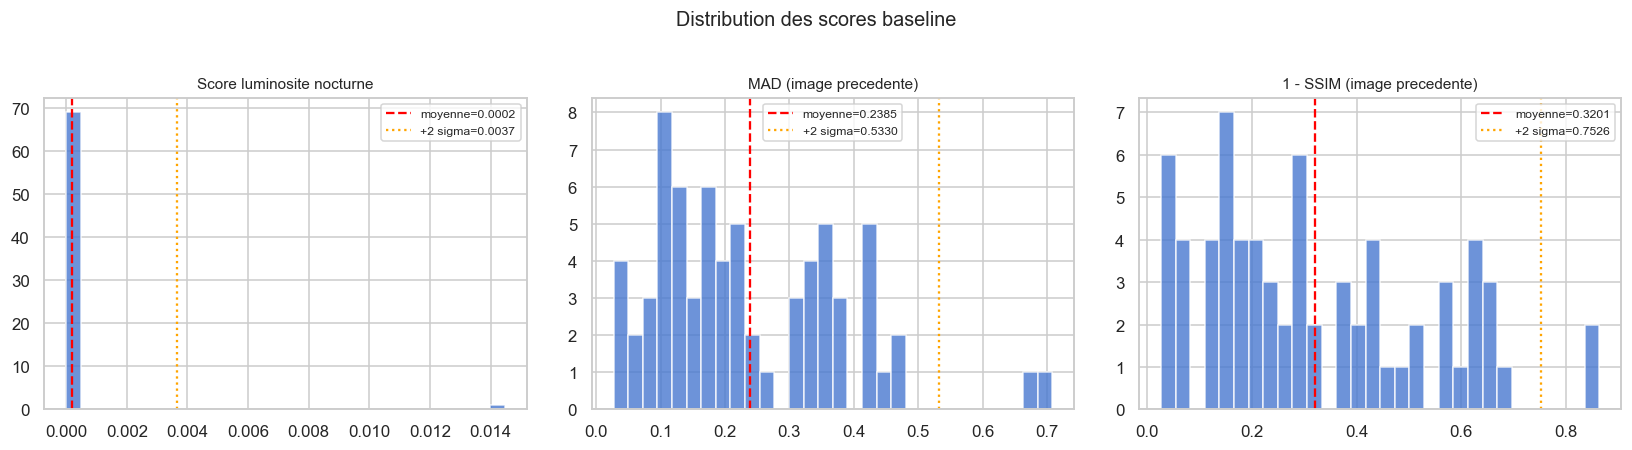

In [6]:
if not scores_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    score_cols = [
        ("night_score", "Score luminosite nocturne"),
        ("mad_prev", "MAD (image precedente)"),
        ("ssim_prev", "1 - SSIM (image precedente)"),
    ]

    for ax, (col, title) in zip(axes, score_cols):
        vals = scores_df[col].dropna()
        if not vals.empty:
            ax.hist(vals, bins=30, edgecolor="white", alpha=0.8)
            ax.axvline(vals.mean(), color="red", ls="--", label=f"moyenne={vals.mean():.4f}")
            ax.axvline(vals.mean() + 2 * vals.std(), color="orange", ls=":",
                       label=f"+2 sigma={vals.mean() + 2*vals.std():.4f}")
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8)

    fig.suptitle("Distribution des scores baseline", fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "04_score_distributions.png", bbox_inches="tight")
    plt.show()
else:
    print("Pas de scores a visualiser.")

## 5. Evolution temporelle des scores

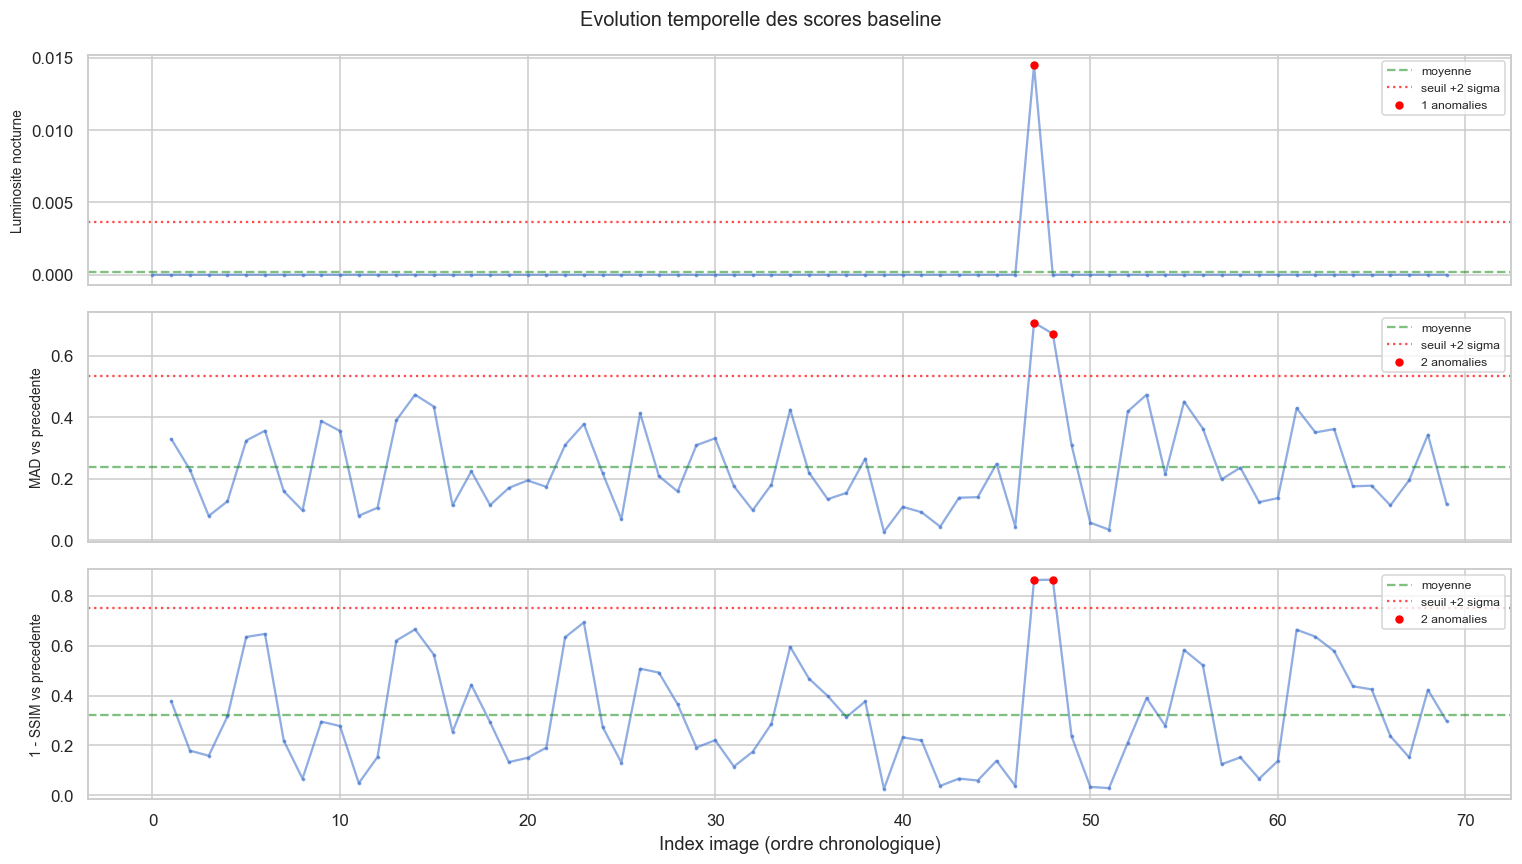

In [7]:
if not scores_df.empty:
    scores_df["image_idx"] = range(len(scores_df))

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    for ax, (col, label) in zip(axes, [
        ("night_score", "Luminosite nocturne"),
        ("mad_prev", "MAD vs precedente"),
        ("ssim_prev", "1 - SSIM vs precedente"),
    ]):
        vals = scores_df[col].dropna()
        idx = scores_df.loc[vals.index, "image_idx"]
        ax.plot(idx, vals, ".-", alpha=0.6, markersize=3)

        if not vals.empty:
            mean_v = vals.mean()
            thresh = mean_v + 2 * vals.std()
            ax.axhline(mean_v, color="green", ls="--", alpha=0.5, label="moyenne")
            ax.axhline(thresh, color="red", ls=":", alpha=0.7, label="seuil +2 sigma")
            # Marquer les anomalies
            anomalies = vals[vals > thresh]
            if not anomalies.empty:
                ax.scatter(
                    scores_df.loc[anomalies.index, "image_idx"],
                    anomalies,
                    color="red", zorder=5, s=20, label=f"{len(anomalies)} anomalies"
                )

        ax.set_ylabel(label, fontsize=9)
        ax.legend(fontsize=8, loc="upper right")

    axes[-1].set_xlabel("Index image (ordre chronologique)")
    fig.suptitle("Evolution temporelle des scores baseline", fontsize=13)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "04_score_timeline.png", bbox_inches="tight")
    plt.show()
else:
    print("Pas de scores a visualiser.")

## 6. Top anomalies detectees

In [8]:
if not scores_df.empty:
    top_n = 10
    top = scores_df.nlargest(top_n, "combined_score")
    print(f"Top {top_n} anomalies (score combine) :\n")
    display_cols = ["filename", "day", "hour", "night_score", "mad_prev", "ssim_prev", "combined_score"]
    print(top[display_cols].to_string(index=False))
else:
    print("Aucun score disponible.")

Top 10 anomalies (score combine) :

                           filename  day  hour  night_score  mad_prev  ssim_prev  combined_score
Kalor_Canon_2014-11-20_17.13.04.jpg   20    17     0.014465  0.707969   0.862844        0.528426
Kalor_Canon_2014-11-20_22.12.53.jpg   20    22     0.000000  0.671646   0.864148        0.511931
 Suki_Canon_2014-11-14_22.12.42.jpg   14    22     0.000000  0.473331   0.664960        0.379430
Kalor_Canon_2014-11-28_17.13.04.jpg   28    17     0.000000  0.429338   0.663804        0.364381
 Suki_Canon_2014-11-15_17.13.14.jpg   15    17     0.000000  0.377872   0.692870        0.356914
Kalor_Canon_2014-11-27_17.13.04.jpg   27    17     0.000000  0.450696   0.582641        0.344446
Kalor_Canon_2014-11-16_23.12.53.jpg   16    23     0.000000  0.424749   0.595139        0.339963
Kalor_Canon_2014-11-14_17.52.26.jpg   14    17     0.000000  0.389891   0.620179        0.336690
 Suki_Canon_2014-11-13_17.13.15.jpg   13    17     0.000000  0.356062   0.646733        0.3

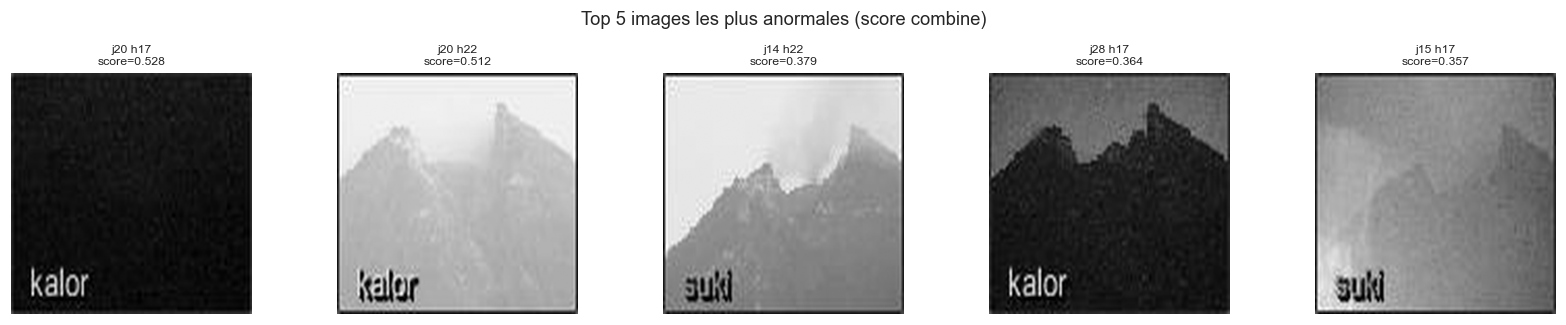

In [9]:
# Visualiser les images les plus anormales
if not scores_df.empty:
    top5 = scores_df.nlargest(5, "combined_score")
    fig, axes = plt.subplots(1, min(5, len(top5)), figsize=(15, 3))
    if len(top5) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, top5.iterrows()):
        # Chercher le local_path dans l'index
        idx_row = df[df["filename"] == row["filename"]]
        if idx_row.empty:
            ax.set_title(row["filename"], fontsize=7)
            ax.axis("off")
            continue

        raw_path = SRC_ROOT / str(idx_row.iloc[0]["local_path"])
        proc_path = detector._resolve_processed_path(idx_row.iloc[0]["local_path"])
        img = MerapiPreprocessor.load_processed_image(proc_path)

        if img is not None:
            ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(f"j{int(row['day'])} h{int(row['hour'])}\nscore={row['combined_score']:.3f}", fontsize=8)
        ax.axis("off")

    fig.suptitle("Top 5 images les plus anormales (score combine)", fontsize=12)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "04_top_anomalies.png", bbox_inches="tight")
    plt.show()

## 7. Comparaison heure fixe

On compare les images prises au meme creneau horaire sur des jours consecutifs.  
Cela permet de detecter des changements specifiques a un moment de la journee  
(ex : incandescence nocturne, panache matinal).

In [10]:
# Choisir les heures les plus representees
if not df_dl.empty:
    hour_counts = df_dl["hour"].value_counts().sort_index()
    # Heures avec au moins 5 images
    good_hours = hour_counts[hour_counts >= 5].index.tolist()
    print(f"Heures avec >= 5 images : {good_hours}")
    print(hour_counts)

Heures avec >= 5 images : []
Series([], Name: count, dtype: int64)


In [11]:
if not df_dl.empty and len(good_hours) > 0:
    # Comparer pour quelques heures representatives (nuit + jour)
    hours_to_compare = []
    for h in [3, 6, 9, 12, 15, 18]:
        if h in good_hours:
            hours_to_compare.append(h)
    if not hours_to_compare:
        hours_to_compare = good_hours[:4]

    year, month = int(df_dl["year"].mode().iloc[0]), int(df_dl["month"].mode().iloc[0])

    fig, axes = plt.subplots(len(hours_to_compare), 1, figsize=(12, 3 * len(hours_to_compare)), sharex=True)
    if len(hours_to_compare) == 1:
        axes = [axes]

    for ax, target_h in zip(axes, hours_to_compare):
        comp = detector.compare_same_hour(df, target_h, year, month)
        if comp.empty:
            ax.set_title(f"Heure {target_h:02d}h — pas de donnees", fontsize=10)
            continue

        days = [f"j{a}-j{b}" for a, b in zip(comp["day_a"], comp["day_b"])]
        x = range(len(days))

        ax.bar(x, comp["mad_score"], alpha=0.6, label="MAD", width=0.4, align="edge")
        ax2 = ax.twinx()
        ax2.plot(x, comp["ssim_score"], "ro-", markersize=4, alpha=0.7, label="1-SSIM")
        ax2.set_ylabel("1-SSIM", fontsize=8, color="red")

        ax.set_ylabel("MAD", fontsize=8)
        ax.set_title(f"Comparaison heure {target_h:02d}h — jours consecutifs", fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(days, rotation=45, fontsize=7)
        ax.legend(loc="upper left", fontsize=8)
        ax2.legend(loc="upper right", fontsize=8)

    fig.suptitle(f"Comparaison heure fixe — {year}/{month:02d}", fontsize=13)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "04_same_hour_comparison.png", bbox_inches="tight")
    plt.show()

## 8. Heatmap jour x heure du score combine

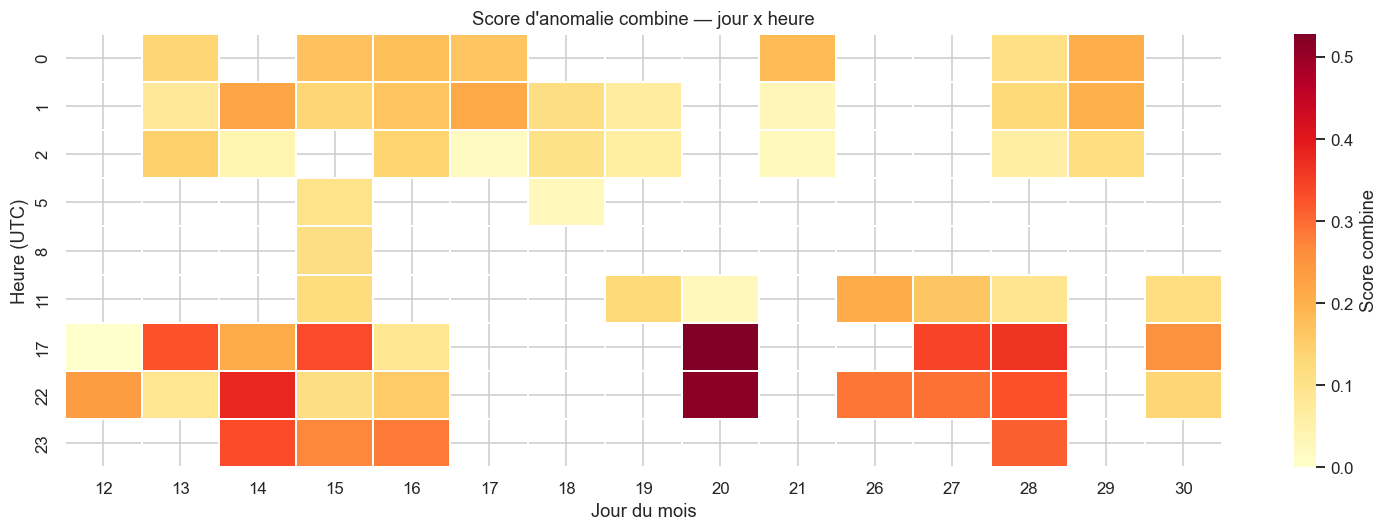

In [12]:
if not scores_df.empty:
    pivot = scores_df.pivot_table(
        index="hour", columns="day", values="combined_score", aggfunc="mean"
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(
        pivot, cmap="YlOrRd", annot=False, fmt=".3f",
        linewidths=0.3, ax=ax, cbar_kws={"label": "Score combine"}
    )
    ax.set_title("Score d'anomalie combine — jour x heure", fontsize=12)
    ax.set_xlabel("Jour du mois")
    ax.set_ylabel("Heure (UTC)")

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "04_heatmap_anomaly.png", bbox_inches="tight")
    plt.show()
else:
    print("Pas de scores pour la heatmap.")

## 9. Correlation entre les scores

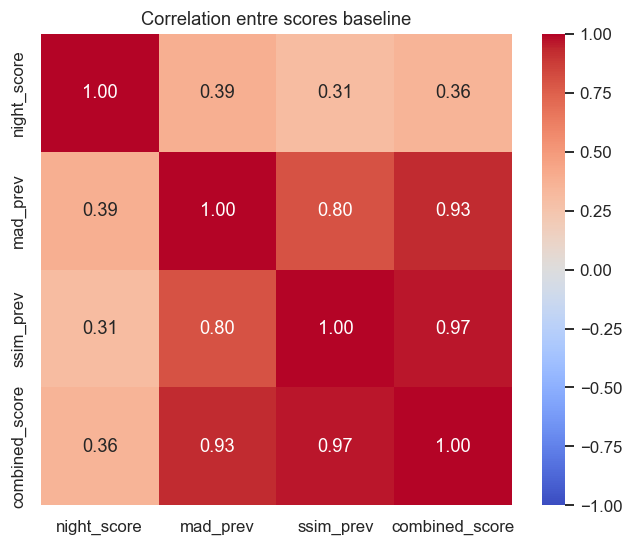

In [13]:
if not scores_df.empty:
    score_cols = ["night_score", "mad_prev", "ssim_prev", "combined_score"]
    corr = scores_df[score_cols].corr()

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, ax=ax, vmin=-1, vmax=1)
    ax.set_title("Correlation entre scores baseline", fontsize=12)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "04_score_correlation.png", bbox_inches="tight")
    plt.show()
else:
    print("Pas de scores pour la matrice de correlation.")

## 10. Mise a jour de l'index

Le score combine est ecrit dans la colonne `anomaly_score` de l'index CSV.

In [14]:
if not scores_df.empty:
    detector.update_index_scores(scores_df, indexer, score_col="combined_score")
    print("Index mis a jour avec les anomaly_score.")
    
    # Verification
    df_updated = indexer.load()
    n_scored = df_updated["anomaly_score"].notna().sum()
    print(f"Images avec anomaly_score : {n_scored} / {len(df_updated)}")
else:
    print("Pas de scores a ecrire.")

15:36:53 | INFO     | src.baselines:326 — 70 scores écrits dans l'index.


Index mis a jour avec les anomaly_score.
Images avec anomaly_score : 70 / 119


## 11. Resume

### Bilan de la Phase 4

| Methode | Description | Utilite |
|---------|------------|--------|
| MAD | Difference absolue pixel-a-pixel | Detecte changements brusques |
| 1 − SSIM | Dissimilarite structurelle | Detecte changements de texture/forme |
| Luminosite nocturne | Pixels lumineux sur fond sombre | Detecte incandescence volcanique |
| Score combine | Moyenne des metriques | Score synthetique de base |

Ces baselines serviront de **reference** pour evaluer les modeles deep learning (Phase 5).  
Les scores sont sauvegardes dans `outputs/scores/` et dans l'index CSV (`anomaly_score`).

**Prochaine etape** : Phase 5 — Autoencodeur convolutif + VAE